<a href="https://colab.research.google.com/github/Yuliia-Safonova/melbourne-housing/blob/main/notebooks/melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Snapshot

## Частина 1. Організація роботи (Colab + GitHub)

**1.1. Створіть репозиторій**  

**1.2. Завантажте датасет з Kaggle**  

**1.3. Додайте датасет у репозиторій**  

**1.4. Отримайте RAW-посилання**  

**1.5. Робота в Colab і збереження назад у GitHub**

## Частина 2. Завдання покроково

### Крок 1. Завантаження даних


In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

In [148]:
# FILE_IN = "melb_data.csv"
FILE_IN = 'https://raw.githubusercontent.com/Yuliia-Safonova/melbourne-housing/refs/heads/main/data/melb_data.csv'

In [149]:
df_origin = pd.read_csv(FILE_IN)
df = df_origin.copy()

display(df.shape)

df.head()

(13580, 21)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


### Крок 2. Перший огляд

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [151]:
print("Data type:")
df.dtypes

Data type:


,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [152]:
df.describe().round(1)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.0,13580.0,13580.0,13580.0,13580.0,13580.0,13518.0,13580.0,7130.0,8205.0,13580.0,13580.0,13580.0
mean,2.9,1075684.1,10.1,3105.3,2.9,1.5,1.6,558.4,152.0,1964.7,-37.8,145.0,7454.4
std,1.0,639310.7,5.9,90.7,1.0,0.7,1.0,3990.7,541.0,37.3,0.1,0.1,4378.6
min,1.0,85000.0,0.0,3000.0,0.0,0.0,0.0,0.0,0.0,1196.0,-38.2,144.4,249.0
25%,2.0,650000.0,6.1,3044.0,2.0,1.0,1.0,177.0,93.0,1940.0,-37.9,144.9,4380.0
50%,3.0,903000.0,9.2,3084.0,3.0,1.0,2.0,440.0,126.0,1970.0,-37.8,145.0,6555.0
75%,3.0,1330000.0,13.0,3148.0,3.0,2.0,2.0,651.0,174.0,1999.0,-37.8,145.1,10331.0
max,10.0,9000000.0,48.1,3977.0,20.0,8.0,10.0,433014.0,44515.0,2018.0,-37.4,145.5,21650.0


In [153]:
display(df.describe(include='all'))

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
count,13580,13580,13580.000000,13580,1.358000e+04,13580,13580,13580,13580.000000,13580.000000,...,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,12211,13580.000000,13580.000000,13580,13580.000000
unique,314,13378,NaN,3,NaN,5,268,58,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33,NaN,NaN,8,NaN
top,Reservoir,5 Margaret St,NaN,h,NaN,S,Nelson,27/05/2017,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Moreland,NaN,NaN,Southern Metropolitan,NaN
freq,359,3,NaN,9449,NaN,9022,1565,473,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1163,NaN,NaN,4695,NaN
mean,NaN,NaN,2.937997,NaN,1.075684e+06,NaN,NaN,NaN,10.137776,3105.301915,...,1.534242,1.610075,558.416127,151.967650,1964.684217,NaN,-37.809203,144.995216,NaN,7454.417378
std,NaN,NaN,0.955748,NaN,6.393107e+05,NaN,NaN,NaN,5.868725,90.676964,...,0.691712,0.962634,3990.669241,541.014538,37.273762,NaN,0.079260,0.103916,NaN,4378.581772
min,NaN,NaN,1.000000,NaN,8.500000e+04,NaN,NaN,NaN,0.000000,3000.000000,...,0.000000,0.000000,0.000000,0.000000,1196.000000,NaN,-38.182550,144.431810,NaN,249.000000
25%,NaN,NaN,2.000000,NaN,6.500000e+05,NaN,NaN,NaN,6.100000,3044.000000,...,1.000000,1.000000,177.000000,93.000000,1940.000000,NaN,-37.856822,144.929600,NaN,4380.000000
50%,NaN,NaN,3.000000,NaN,9.030000e+05,NaN,NaN,NaN,9.200000,3084.000000,...,1.000000,2.000000,440.000000,126.000000,1970.000000,NaN,-37.802355,145.000100,NaN,6555.000000
75%,NaN,NaN,3.000000,NaN,1.330000e+06,NaN,NaN,NaN,13.000000,3148.000000,...,2.000000,2.000000,651.000000,174.000000,1999.000000,NaN,-37.756400,145.058305,NaN,10331.000000


In [154]:
print('Missing values:\n')
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_report = pd.DataFrame({
    'count': missing,
    'type': df.dtypes.astype(str),
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,type,%
BuildingArea,6450,float64,47.5
Car,62,float64,0.5
CouncilArea,1369,object,10.1
YearBuilt,5375,float64,39.6


### Крок 3. Очищення

In [155]:
# Перейменування колонок

print('Rename columns:\n')

df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Suburb': 'suburb',
    'Address': 'address',
    'Rooms': 'rooms',
    'Type': 'type',
    'Price': 'price',
    'Method': 'method',
    'SellerG': 'seller',
    'Date': 'date',
    'Distance': 'distance',
    'Postcode': 'postcode',
    'Bedroom2': 'bedrooms',
    'Bathroom': 'bathrooms',
    'Car': 'car_spaces',
    'Landsize': 'land_size',
    'BuildingArea': 'building_area',
    'YearBuilt': 'year_built',
    'CouncilArea': 'council_area',
    'Lattitude': 'latitude',
    'Longtitude': 'longitude',
    'Regionname': 'region_name',
    'Propertycount': 'property_count'
})

print(list(df.columns))

Rename columns:

['suburb', 'address', 'rooms', 'type', 'price', 'method', 'seller', 'date', 'distance', 'postcode', 'bedrooms', 'bathrooms', 'car_spaces', 'land_size', 'building_area', 'year_built', 'council_area', 'latitude', 'longitude', 'region_name', 'property_count']


In [156]:
clean = df.copy() # копія датасета

# Видалення технічного стовпця
if 'Unnamed: 0' in clean.columns:
    clean = clean.drop(columns='Unnamed: 0')

# Перетворення дати
clean['date'] = pd.to_datetime(clean['date'], dayfirst=True)

# Заміна хибних нулів на NaN
clean.loc[clean['land_size'] == 0, 'land_size'] = np.nan
clean.loc[clean['building_area'] == 0, 'building_area'] = np.nan

# Перевірка року побудови
clean.loc[clean['year_built'] < 1700, 'year_built'] = np.nan

# Перевірка дублікатів
print('Duplicates:', clean.duplicated().sum())  # в нашому випадку 0 дублікатів
clean = clean.drop_duplicates()                 # якщо були б дублікати, прибираємо їх

# Перевірка пропусків у цільовій змінній
print('Missing values in price:', clean['price'].isna().sum())

# На випадок, якщо пропуски є — видаляємо такі рядки
clean = clean.dropna(subset=['price'])
print('Shape after dropping missing price:', clean.shape)

# Перевіряємо розмір після чищення
print('Shape after cleaning:', clean.shape)

Duplicates: 0
Missing values in price: 0
Shape after dropping missing price: (13580, 21)
Shape after cleaning: (13580, 21)


### Крок 4. Дослідження (EDA)

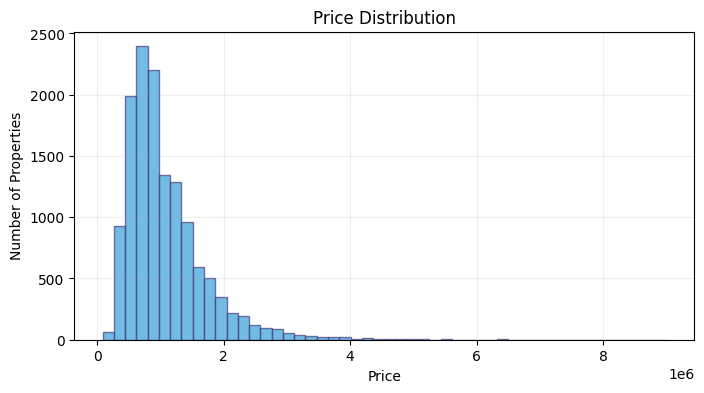

In [157]:
# Розподіл ціни

plt.figure(figsize=(8, 4))

plt.hist(clean['price'], bins=50, color='#379fdb', edgecolor='#473c7a', alpha=0.7)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of Properties')
plt.grid(axis='y', alpha=0.2)
plt.grid(axis='x', alpha=0.2)

plt.show()

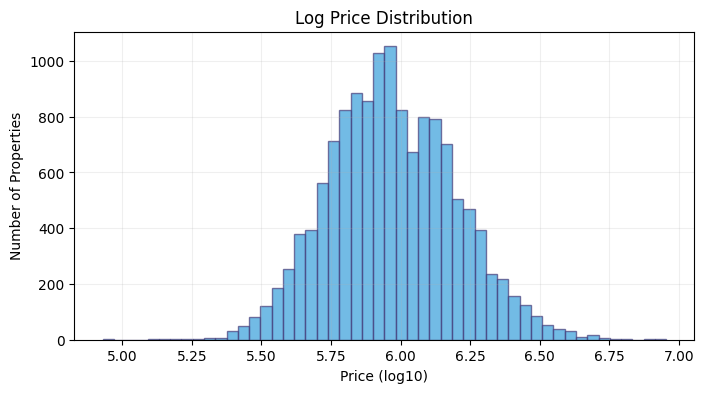

In [158]:
# Логарифм ціни

plt.figure(figsize=(8, 4))

plt.hist(np.log10(clean['price']), bins=50, color='#379fdb', edgecolor='#473c7a', alpha=0.7)

plt.title('Log Price Distribution')
plt.xlabel('Price (log10)')
plt.ylabel('Number of Properties')
plt.grid(axis='y', alpha=0.2)
plt.grid(axis='x', alpha=0.2)

plt.show()

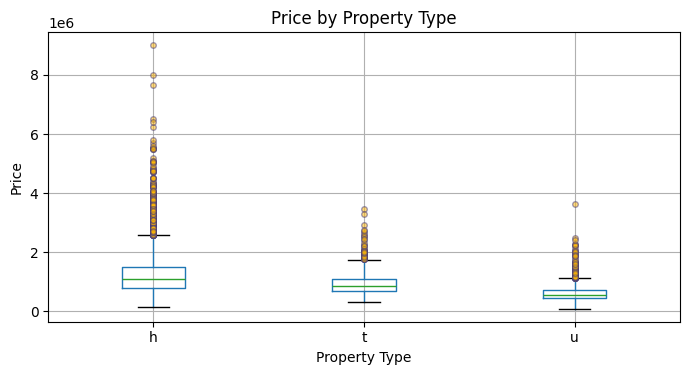

In [159]:
# Ціна за типом житла

fig, ax = plt.subplots(figsize=(7, 4))

clean.boxplot(
    column='price',
    by='type',
    ax=ax,
    flierprops=dict(
        marker='o',
        markerfacecolor='#ffb703',
        markeredgecolor='#473c7a',
        markersize=4,
        alpha=0.5
    )
)

ax.set_title('Price by Property Type')
ax.set_xlabel('Property Type')
ax.set_ylabel('Price')

plt.suptitle('')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

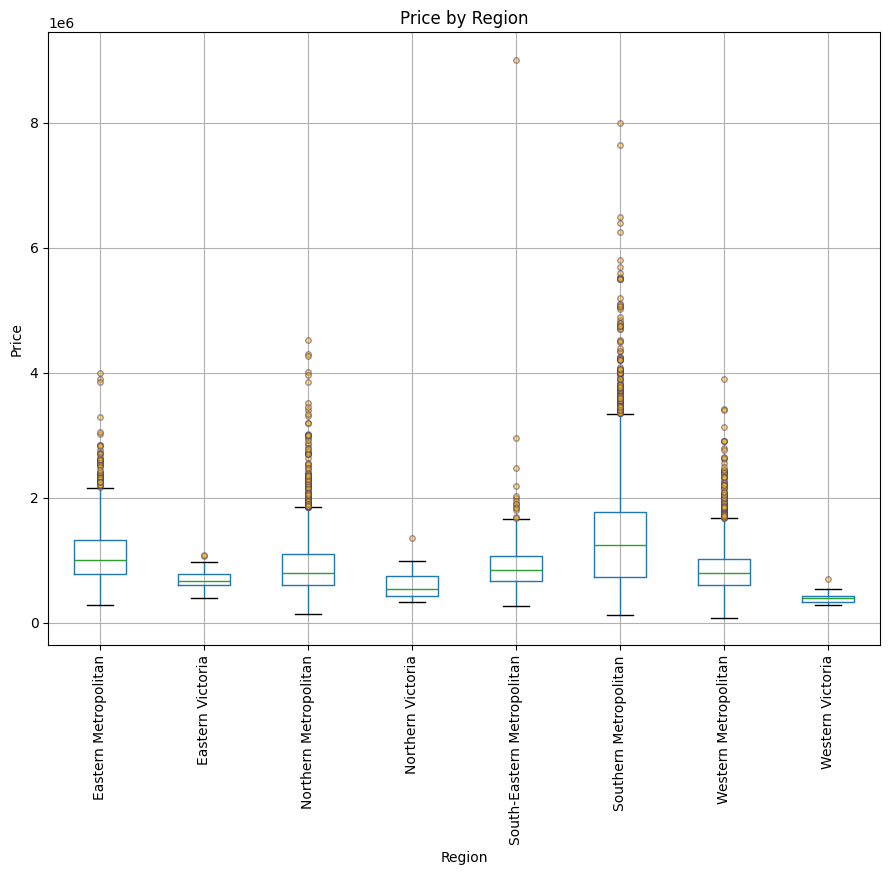

In [160]:
# Ціна за регіоном

fig, ax = plt.subplots(figsize=(9, 9))

clean.boxplot(
    column='price',
    by='region_name',
    ax=ax,
    flierprops=dict(
        marker='o',
        markerfacecolor='#ffb703',
        markeredgecolor='#473c7a',
        markersize=4,
        alpha=0.5
    )
)

ax.set_title('Price by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Price')

plt.suptitle('')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [161]:
# Кореляція числових ознак із ціною

num = clean.select_dtypes(include='number')
corr_price = (num.corr()['price'].drop('price').sort_values(key=abs, ascending=False)).round(3)

print('Correlation of Features with Price:\n')
print(corr_price)
print()

Correlation of Features with Price:

rooms             0.497
bedrooms          0.476
bathrooms         0.467
year_built       -0.332
car_spaces        0.239
latitude         -0.213
longitude         0.204
distance         -0.163
postcode          0.108
building_area     0.092
property_count   -0.042
land_size         0.023
Name: price, dtype: float64



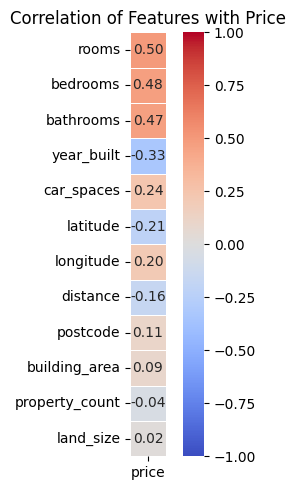

In [162]:
# Heatmap кореляцій

fig, ax = plt.subplots(figsize=(4, 5))

sns.heatmap(
    corr_price.to_frame(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 10}
)

ax.set_title('Correlation of Features with Price')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [163]:
# Пошук ознак, які дублюють одна одну

display(num.corr().round(2))

,rooms,price,distance,postcode,bedrooms,bathrooms,car_spaces,land_size,building_area,year_built,latitude,longitude,property_count
rooms,1.00,0.50,0.29,0.06,0.94,0.59,0.41,0.00,0.12,-0.07,0.02,0.10,-0.08
price,0.50,1.00,-0.16,0.11,0.48,0.47,0.24,0.02,0.09,-0.33,-0.21,0.20,-0.04
distance,0.29,-0.16,1.00,0.43,0.30,0.13,0.26,0.01,0.10,0.25,-0.13,0.24,-0.05
postcode,0.06,0.11,0.43,1.00,0.06,0.11,0.05,0.03,0.06,0.04,-0.41,0.45,0.06
bedrooms,0.94,0.48,0.30,0.06,1.00,0.58,0.41,0.00,0.12,-0.05,0.02,0.10,-0.08
bathrooms,0.59,0.47,0.13,0.11,0.58,1.00,0.32,0.03,0.11,0.15,-0.07,0.12,-0.05
car_spaces,0.41,0.24,0.26,0.05,0.41,0.32,1.00,0.02,0.10,0.11,-0.00,0.06,-0.02
land_size,0.00,0.02,0.01,0.03,0.00,0.03,0.02,1.00,0.50,0.08,0.01,0.01,-0.00
building_area,0.12,0.09,0.10,0.06,0.12,0.11,0.10,0.50,1.00,0.02,0.04,-0.02,-0.03
year_built,-0.07,-0.33,0.25,0.04,-0.05,0.15,0.11,0.08,0.02,1.00,0.06,-0.00,0.01


In [164]:
clean[['rooms', 'bedrooms']].corr()

,rooms,bedrooms
rooms,1.00000,0.94419
bedrooms,0.94419,1.00000


**Висновки**

1. Найдорожчим типом житла є будинки (type = 'h'), а також об’єкти в регіоні Southern Metropolitan. За boxplot видно, що медіанна ціна будинків вища, ніж у таунхаусів (t) та квартир (u). Регіон Southern Metropolitan також має найбільший розкид цін і багато високих викидів, що свідчить про наявність преміального сегменту нерухомості.  

2. Найсильніше з вартістю житла пов’язані кількість кімнат (rooms), кількість ванних кімнат (bathrooms) та кількість спалень (bedrooms). Кореляції за цими змінними знаходяться приблизно на рівні 0.47–0.50 (0.467-0.497), що свідчить про позитивний зв’язок: зі збільшенням кількості кімнат ціна зростає. Ознаки rooms і bedrooms мають дуже високу кореляцію між собою, тому вони частково дублюють інформацію і це потрібно врахувати під час побудови моделі.  

3. Відстань до центру (distance) має слабкий негативний зв’язок (= -0.16), тобто житло, розташоване далі від центру, у середньому трохи дешевше, але залежність не є вираженою.  

4. Також помітний від’ємний зв’язок із роком побудови (year_built = -0.29). Це означає, що більш нові будинки в середньому дорожчі, хоча цей зв’язок не є дуже сильним.  

5. Інші ознаки, такі як площа ділянки (land_size), кількість парковочних місць (car_spaces), координати (latitude, longitude), а також (property_count, postcode), мають слабкий або майже відсутній лінійний зв’язок із ціною.

### Крок 5. Нові ознаки (feature engineering)

In [165]:
clean.columns

Index(['suburb', 'address', 'rooms', 'type', 'price', 'method', 'seller',
       'date', 'distance', 'postcode', 'bedrooms', 'bathrooms', 'car_spaces',
       'land_size', 'building_area', 'year_built', 'council_area', 'latitude',
       'longitude', 'region_name', 'property_count'],
      dtype='object')

In [166]:
fe = clean.copy()

# 1. Частини дати продажу
fe['sale_year'] = fe['date'].dt.year
fe['sale_month'] = fe['date'].dt.month

# 2. Вік будинку на момент продажу
fe['house_age'] = fe['sale_year'] - fe['year_built']
fe.loc[fe['house_age'] < 0, 'house_age'] = np.nan

# 3. Прапорці наявності пропусків
fe['has_building_area'] = fe['building_area'].notna().astype(int)
fe['has_year_built'] = fe['year_built'].notna().astype(int)

# 4. Видалення зайвих стовпців
# suburb навмисно залишаємо — частотне кодування рахуємо пізніше, вже після train_test_split, щоб уникнути витоку даних
fe = fe.drop(
    columns=[
        'address',
        'seller',
        'date',
        'bedrooms',
        'year_built'
    ],
    errors='ignore'
)

print(fe.head())
print()
print(fe.columns)

       suburb  rooms type      price method  distance  postcode  bathrooms  \
0  Abbotsford      2    h  1480000.0      S       2.5    3067.0        1.0   
1  Abbotsford      2    h  1035000.0      S       2.5    3067.0        1.0   
2  Abbotsford      3    h  1465000.0     SP       2.5    3067.0        2.0   
3  Abbotsford      3    h   850000.0     PI       2.5    3067.0        2.0   
4  Abbotsford      4    h  1600000.0     VB       2.5    3067.0        1.0   

   car_spaces  land_size  ...  council_area latitude  longitude  \
0         1.0      202.0  ...         Yarra -37.7996   144.9984   
1         0.0      156.0  ...         Yarra -37.8079   144.9934   
2         0.0      134.0  ...         Yarra -37.8093   144.9944   
3         1.0       94.0  ...         Yarra -37.7969   144.9969   
4         2.0      120.0  ...         Yarra -37.8072   144.9941   

             region_name property_count  sale_year  sale_month  house_age  \
0  Northern Metropolitan         4019.0       2016 

### Крок 6. Підготовка до моделювання

In [167]:
fe.dtypes

,0
suburb,object
rooms,int64
type,object
price,float64
method,object
distance,float64
postcode,float64
bathrooms,float64
car_spaces,float64
land_size,float64


In [168]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# 1. Ціль і ознаки

y = fe['price']
X = fe.drop(columns='price')

# 2. Поділ на навчальну і тестову вибірки
# (робимо split ДО розрахунку suburb_freq, щоб уникнути витоку даних)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

X_train = X_train.copy()
X_test = X_test.copy()

# 3. Частотне кодування suburb — рахуємо ТІЛЬКИ на train

suburb_freq_map = X_train['suburb'].value_counts()

X_train['suburb_freq'] = X_train['suburb'].map(suburb_freq_map)
X_test['suburb_freq'] = X_test['suburb'].map(suburb_freq_map)

# Якщо в test трапиться suburb, якого немає в train — заповнюємо медіаною
X_train['suburb_freq'] = X_train['suburb_freq'].fillna(suburb_freq_map.median())
X_test['suburb_freq'] = X_test['suburb_freq'].fillna(suburb_freq_map.median())

# suburb більше не потрібна — прибираємо
X_train = X_train.drop(columns='suburb')
X_test = X_test.drop(columns='suburb')

# 4. Числові та категоріальні ознаки

cat_cols = ['type', 'method', 'region_name', 'council_area']
num_cols = [col for col in X_train.columns if col not in cat_cols]

# 5. Підготовка даних

preprocess = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (10864, 20)
X_test: (2716, 20)
y_train: (10864,)
y_test: (2716,)


### Крок 7. Модель і прогноз

In [169]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Функція для оцінки моделей

def evaluate(model, name):
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f'\n{name}')
    print(f'MAE : {mae:,.0f}')
    print(f'RMSE: {rmse:,.0f}')
    print(f'R²  : {r2:.3f}')

    return pipe

In [170]:
# Базова модель

dummy_model = evaluate(DummyRegressor(strategy='mean'), 'Dummy Regressor')


Dummy Regressor
MAE : 461,258
RMSE: 630,259
R²  : -0.000


In [171]:
# Лінійна регресія (проста модель)

linear_model = evaluate(LinearRegression(), 'Linear Regression')


Linear Regression
MAE : 256,164
RMSE: 372,734
R²  : 0.650


In [172]:
# Випадковий ліс

forest_model = evaluate(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE), 'Random Forest')


Random Forest
MAE : 162,290
RMSE: 268,604
R²  : 0.818


In [173]:
# Важливість ознак

feature_names = forest_model.named_steps['prep'].get_feature_names_out()

feature_names = (
    pd.Series(feature_names)
      .str.replace('num__', '', regex=False)
      .str.replace('cat__', '', regex=False)
      .str.replace('region_name_', '', regex=False)
      .str.replace('council_area_', '', regex=False)
      .str.replace('type_', 'type: ', regex=False)
      .str.replace('method_', 'method: ', regex=False)
)

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': forest_model.named_steps['model'].feature_importances_.round(3)
}).sort_values('importance')

importances.tail(10)

,feature,importance
12,house_age,0.026
3,bathrooms,0.030
7,latitude,0.042
6,building_area,0.046
8,longitude,0.053
5,land_size,0.079
18,type: u,0.089
1,distance,0.136
0,rooms,0.174
29,Southern Metropolitan,0.209


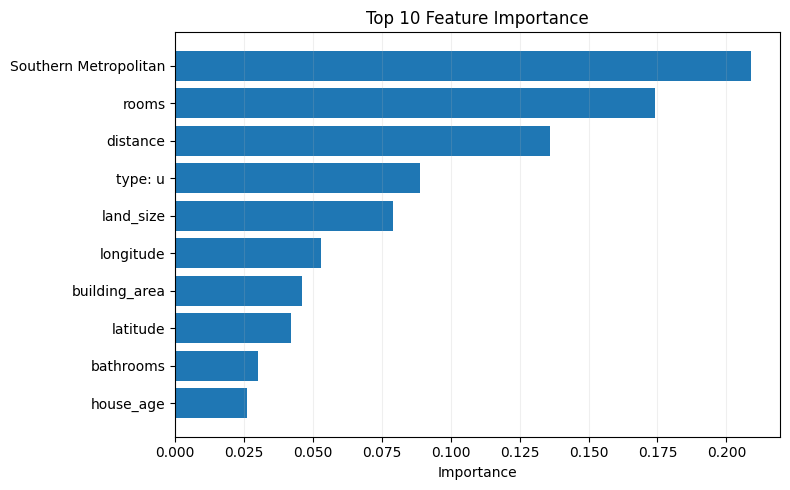

In [174]:
top = importances.tail(10)

plt.figure(figsize=(8, 5))
plt.barh(top['feature'], top['importance'])

plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

*Висновок щодо моделей*

Базова модель `Dummy Regressor`, яка завжди прогнозує середню ціну, показала найгірший результат (R² = 0.000), тобто практично не пояснює змінюваність цін і є лише орієнтиром для порівняння.

`Лінійна регресія` значно покращила якість прогнозування: середня абсолютна помилка становить близько 257 тис., а коефіцієнт R² = 0.648. Це означає, що модель пояснює приблизно 65% варіації цін на житло.

Найкращий результат показав `Random Forest`. Для нього MAE = 163 тис., RMSE = 270 тис., а R² = 0.815, тобто модель пояснює понад 81% варіації цін. Це свідчить про те, що випадковий ліс значно краще враховує складні та нелінійні залежності між характеристиками нерухомості й ціною.

*Висновок щодо важливості ознак*

За результатами моделі `Random Forest`, найбільший вплив на прогноз ціни мають регіон розташування (region_name), кількість кімнат (rooms) та відстань до центру міста (distance). На ціну також впливає тип житла (type) і площа земельної ділянки (land_size).

Менший вплив мають географічні координати, площа будинку, кількість ванних кімнат та кількість об'єктів нерухомості в районі (property_count). Це означає, що під час оцінки вартості житла найбільш важливими є розташування та основні характеристики самого будинку.

### Крок 8. Висновки і README

In [175]:
# Прогноз для одного прикладу

example = X_test.iloc[[0]]

predicted_price = forest_model.predict(example)[0]
actual_price = y_test.iloc[0]

print(f'Predicted price: {predicted_price:,.2f}')
print(f'Actual price:    {actual_price:,.2f}')
print('-' * 30)
print(f'Error:          {predicted_price - actual_price:,.2f}')
print(f'Error %:        {np.abs((predicted_price - actual_price) / actual_price):,.2%}')

Predicted price: 2,136,497.50
Actual price:    2,600,000.00
------------------------------
Error:          -463,502.50
Error %:        17.83%


## ВИСНОВКИ

### Мета проєкту  
Побудувати модель машинного навчання для прогнозування вартості житла на основі характеристик нерухомості з датасету *Melbourne Housing Snapshot*.

### Очищення даних
**Під час підготовки даних було:**

- видалено технічні стовпці  
- перетворено дату продажу у формат datetime  
- замінено некоректні нульові значення площі на пропуски  
- виправлено некоректні значення року побудови  
- перевірено та видалено дублікати  
- перевірено пропуски в цільовій змінній (price) перед розбиттям на вибірки
- створено нові ознаки (рік і місяць продажу, вік будинку, індикатори пропусків та частотне кодування району, розраховане окремо на train і test для запобігання витоку даних)

### Результати аналізу

Дослідження показало, що ціна житла має правосторонньо скошений розподіл. Найбільший зв'язок із ціною мають кількість кімнат, кількість ванних кімнат та кількість спалень. Також виявлено сильну кореляцію між ознаками rooms і bedrooms, що свідчить про часткове дублювання інформації.

### Результати моделей
**Було порівняно три моделі:**

| Model             |         MAE |        RMSE |        R² |
| ----------------- | ----------: | ----------: | --------: |
| Dummy Regressor   |     461 258 |     630 259 |     0.000 |
| Linear Regression |     257 177 |     374 051 |     0.648 |
| Random Forest     | **162 870** | **270 754** | **0.815** |
  

Найкращий результат показала модель Random Forest, яка пояснює ≈ 81–82% варіації цін та має найменшу середню помилку прогнозу.

### Найважливіші ознаки

За результатами Random Forest найбільший вплив на прогноз мають:

- регіон розташування  
- кількість кімнат  
- відстань до центру  
- тип житла  
- площа земельної ділянки

### Можливі покращення

- Використати більш потужні алгоритми, наприклад LightGBM або XGBoost.
- Створити додаткові ознаки (наприклад, співвідношення площі будинку до площі ділянки або взаємодію між характеристиками житла).
- Логарифмувати цільову змінну (price), оскільки її розподіл правосторонньо скошений — це могло б покращити якість лінійної регресії.
- Перевірити стабільність результатів за допомогою крос-валідації замість одного train/test split.